# Sentiment / Emotion Classification — Fixed Version
RNN vs LSTM vs GRU on the `dair-ai/emotion` dataset.

**Fixes applied:**
- Smaller recurrent layers (128 units instead of 500) — the original 500-unit layers were too large for 100-length sequences and got stuck in a bad plateau (near-random accuracy) for RNN and LSTM.
- Lower dropout (0.3 instead of 0.5).
- `EarlyStopping patience` increased to 15 so models get more time to break out of the plateau seen in the original GRU run.
- Added `clipnorm=1.0` to Adam optimizer for training stability (prevents exploding/vanishing gradient issues common in RNN/LSTM).
- Fixed the evaluate() bug: original code called `model.evaluate(...)` (the leftover RNN object) for the LSTM and GRU print statements instead of `lstm_model` / `gru_model` — so the printed LSTM/GRU test loss lines were silently showing the RNN's numbers, not their own.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

c:\Krishna_Great_Productions\Sentimental\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
emmotions_dataset = load_dataset("dair-ai/emotion")

In [3]:
train_text = emmotions_dataset['train']['text']
train_label = emmotions_dataset['train']['label']
test_text = emmotions_dataset['test']['text']
test_label = emmotions_dataset['test']['label']
labels_names = emmotions_dataset['train'].features['label'].names
labels_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [4]:
df_train = pd.DataFrame({'text': train_text, 'label_id': train_label})
df_train['emotion'] = df_train['label_id'].map(dict(enumerate(labels_names)))

df_test = pd.DataFrame({'text': test_text, 'label_id': test_label})
df_test['emotion'] = df_test['label_id'].map(dict(enumerate(labels_names)))

df_train.head()

,text,label_id,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


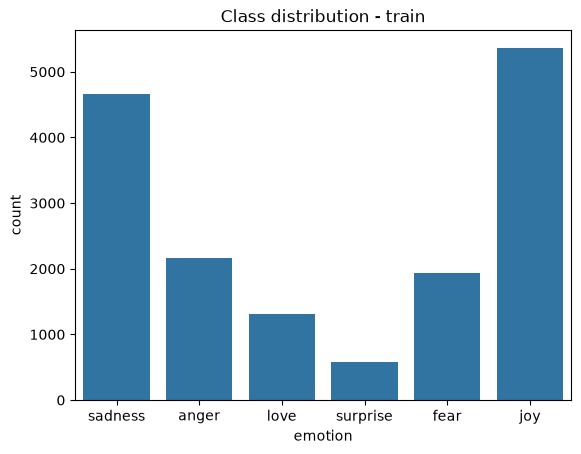

In [5]:
sns.countplot(x='emotion', data=df_train)
plt.title("Class distribution - train")
plt.show()

# Data PreProcessing - NLP

In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<unk>")
tokenizer.fit_on_texts(df_train['text'])

train_sequences = tokenizer.texts_to_sequences(df_train['text'])
test_sequences = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequences = pad_sequences(train_sequences, padding='post', maxlen=max_len, truncating='post')
padded_test_sequences = pad_sequences(test_sequences, padding='post', maxlen=max_len, truncating='post')

padded_train_sequences.shape, padded_test_sequences.shape

((16000, 100), (2000, 100))

In [7]:
label_to_id = dict(zip(labels_names, range(len(labels_names))))

train_labels = np.array(df_train['emotion'].map(label_to_id).values)
test_labels = np.array(df_test['emotion'].map(label_to_id).values)

num_classes = len(np.unique(train_labels))
num_classes

6

In [8]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [9]:
from tensorflow.keras.callbacks import EarlyStopping

# patience raised from 10 -> 15: RNN/LSTM/GRU can sit on a plateau for 10+ epochs
# before breaking out (see the original GRU run, which broke out around epoch 16)
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

## Simple RNN model

In [10]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam

rnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    SimpleRNN(units=128),
    Dropout(0.3),
    Dense(units=num_classes, activation='softmax')
])

rnn_model.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
rnn_history = rnn_model.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences, test_labels),
    epochs=50,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequences, test_labels)
print(f"Simple RNN Test Loss/Accuracy: {rnn_loss:.4f} / {rnn_accuracy:.4f}")

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.1581 - loss: 1.8224 - val_accuracy: 0.0875 - val_loss: 1.8147
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.1543 - loss: 1.7988 - val_accuracy: 0.1465 - val_loss: 1.8013
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.1488 - loss: 1.7984 - val_accuracy: 0.3450 - val_loss: 1.7929
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.1384 - loss: 1.7948 - val_accuracy: 0.0330 - val_loss: 1.8059
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.1359 - loss: 1.7932 - val_accuracy: 0.1145 - val_loss: 1.7761
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.1556 - loss: 1.7943 - val_accuracy: 0.0330 - val_loss: 1.8051
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.1170 - loss: 1.7933 - val_accuracy: 0.3470 - val_loss: 1.7844
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.1591 - loss: 1.7933 - 

## LSTM model

In [12]:
lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    LSTM(units=128, return_sequences=True),
    Dropout(0.3),
    LSTM(units=64),
    Dropout(0.3),
    Dense(units=num_classes, activation='softmax')
])

lstm_model.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
lstm_history = lstm_model.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences, test_labels),
    epochs=50,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

# FIX: was calling model.evaluate(...) (the leftover RNN object) here — now uses lstm_model
lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequences, test_labels)
print(f"LSTM Test Loss/Accuracy: {lstm_loss:.4f} / {lstm_accuracy:.4f}")

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 56s 208ms/step - accuracy: 0.1647 - loss: 1.7937 - val_accuracy: 0.0330 - val_loss: 1.8076
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 62s 247ms/step - accuracy: 0.1499 - loss: 1.7934 - val_accuracy: 0.2905 - val_loss: 1.7939
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 55s 220ms/step - accuracy: 0.1794 - loss: 1.7924 - val_accuracy: 0.0330 - val_loss: 1.8222
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 220ms/step - accuracy: 0.1318 - loss: 1.7931 - val_accuracy: 0.2905 - val_loss: 1.7845
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 55s 221ms/step - accuracy: 0.1656 - loss: 1.7926 - val_accuracy: 0.0330 - val_loss: 1.8114
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 52s 209ms/step - accuracy: 0.1726 - loss: 1.7926 - val_accuracy: 0.1120 - val_loss: 1.7997
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 54s 215ms/step - accuracy: 0.1887 - loss: 1.7927 - val_accuracy: 0.0795 - val_loss: 1.8049
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 52s 207ms/step - accuracy: 0.1651 - loss: 1

## GRU model

In [14]:
gru_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    GRU(units=128, return_sequences=True),
    Dropout(0.3),
    GRU(units=64),
    Dropout(0.3),
    Dense(units=num_classes, activation='softmax')
])

gru_model.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
gru_history = gru_model.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences, test_labels),
    epochs=50,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

# FIX: was calling model.evaluate(...) (the leftover RNN object) here — now uses gru_model
gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequences, test_labels)
print(f"GRU Test Loss/Accuracy: {gru_loss:.4f} / {gru_accuracy:.4f}")

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 55s 205ms/step - accuracy: 0.1522 - loss: 1.7944 - val_accuracy: 0.1120 - val_loss: 1.7825
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 80s 196ms/step - accuracy: 0.1596 - loss: 1.7938 - val_accuracy: 0.0330 - val_loss: 1.7853
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 49s 196ms/step - accuracy: 0.1479 - loss: 1.7937 - val_accuracy: 0.0795 - val_loss: 1.7818
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 49s 198ms/step - accuracy: 0.1657 - loss: 1.7933 - val_accuracy: 0.0795 - val_loss: 1.8161
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 49s 197ms/step - accuracy: 0.1519 - loss: 1.7934 - val_accuracy: 0.1375 - val_loss: 1.7911
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 50s 199ms/step - accuracy: 0.1505 - loss: 1.7929 - val_accuracy: 0.2905 - val_loss: 1.7878
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 49s 197ms/step - accuracy: 0.1404 - loss: 1.7929 - val_accuracy: 0.3475 - val_loss: 1.7879
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 40s 161ms/step - accuracy: 0.1443 - loss: 1

## Compare all three models

In [16]:
rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequences, test_labels, verbose=0)
lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequences, test_labels, verbose=0)
gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequences, test_labels, verbose=0)

result_df = pd.DataFrame({
    "Model": ['RNN', 'LSTM', 'GRU'],
    "Test Loss": [rnn_loss, lstm_loss, gru_loss],
    "Test Accuracy": [rnn_accuracy, lstm_accuracy, gru_accuracy]
})
result_df

,Model,Test Loss,Test Accuracy
0,RNN,1.708564,0.2890
1,LSTM,1.780750,0.3475
2,GRU,1.766575,0.2905


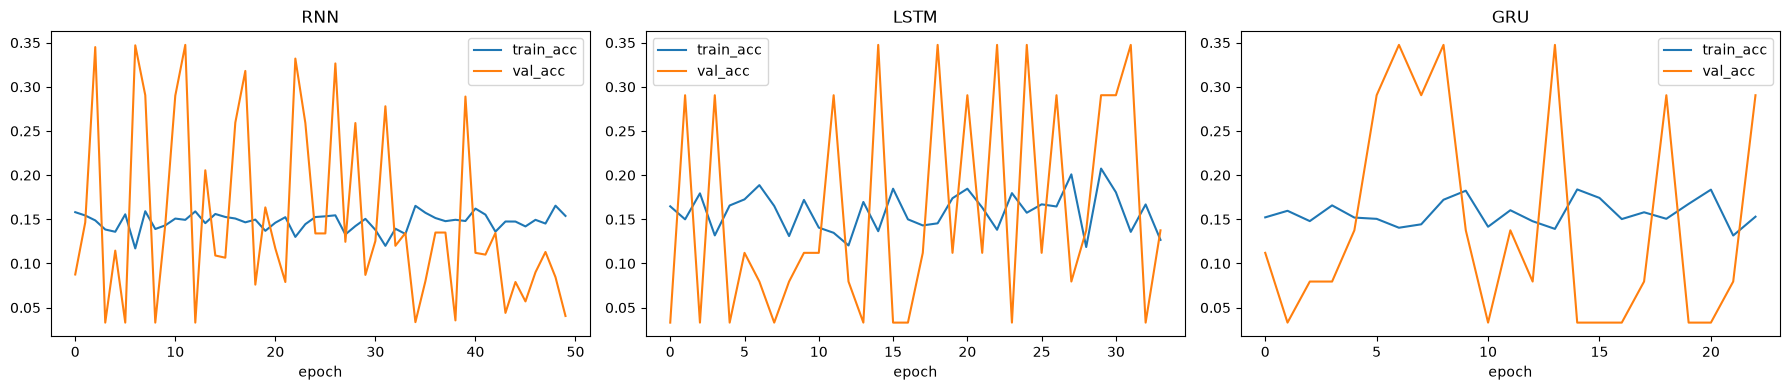

In [17]:
# Optional: plot training curves to visually confirm each model actually learned
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, history, name in zip(axes, [rnn_history, lstm_history, gru_history], ['RNN', 'LSTM', 'GRU']):
    ax.plot(history.history['accuracy'], label='train_acc')
    ax.plot(history.history['val_accuracy'], label='val_acc')
    ax.set_title(name)
    ax.set_xlabel('epoch')
    ax.legend()
plt.tight_layout()
plt.show()

In [19]:
bilstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    Bidirectional(LSTM(units=64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(units=32)),
    Dropout(0.3),
    Dense(units=num_classes, activation='softmax')
])

In [20]:
bilstm_model.compile(
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
bilstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

In [23]:
bilstm_history = bilstm_model.fit(
    padded_train_sequences,
    train_labels,
    validation_data=(padded_test_sequences, test_labels),
    epochs=50,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 36s 117ms/step - accuracy: 0.4571 - loss: 1.3802 - val_accuracy: 0.7850 - val_loss: 0.6789
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 29s 116ms/step - accuracy: 0.8894 - loss: 0.3509 - val_accuracy: 0.8885 - val_loss: 0.3462
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 109ms/step - accuracy: 0.9404 - loss: 0.1911 - val_accuracy: 0.8985 - val_loss: 0.3002
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 100ms/step - accuracy: 0.9567 - loss: 0.1365 - val_accuracy: 0.8860 - val_loss: 0.3806
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 26s 105ms/step - accuracy: 0.9661 - loss: 0.1063 - val_accuracy: 0.8835 - val_loss: 0.4050
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 110ms/step - accuracy: 0.9724 - loss: 0.0838 - val_accuracy: 0.9050 - val_loss: 0.3576
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 110ms/step - accuracy: 0.9779 - loss: 0.0692 - val_accuracy: 0.9000 - val_loss: 0.3888
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 110ms/step - accuracy: 0.9817 - loss: 0

In [24]:
bilstm_loss, bilstm_accuracy = bilstm_model.evaluate(padded_test_sequences, test_labels)
print(f"BiLSTM Test Loss/Accuracy: {bilstm_loss:.4f} / {bilstm_accuracy:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8985 - loss: 0.3002
BiLSTM Test Loss/Accuracy: 0.3002 / 0.8985


In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(model, X_test, y_test, class_names, title="Confusion Matrix"):
    # Predict
    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

    # Classification report (precision, recall, f1 per class)
    print(classification_report(y_test, y_pred, target_names=class_names))

    return cm

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


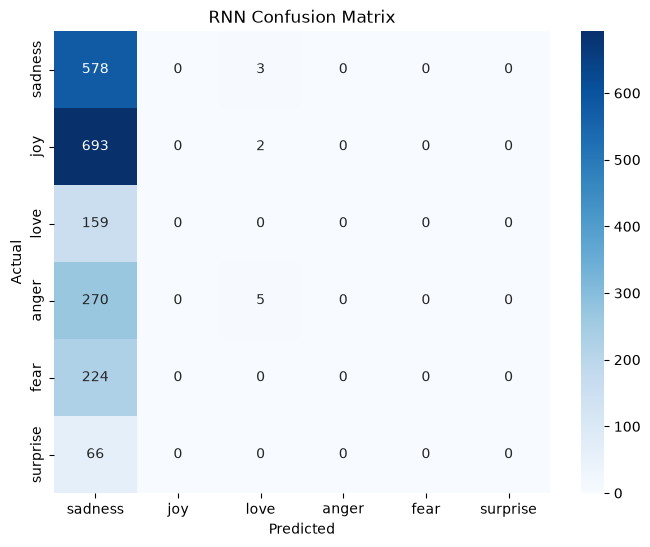

              precision    recall  f1-score   support

     sadness       0.29      0.99      0.45       581
         joy       0.00      0.00      0.00       695
        love       0.00      0.00      0.00       159
       anger       0.00      0.00      0.00       275
        fear       0.00      0.00      0.00       224
    surprise       0.00      0.00      0.00        66

    accuracy                           0.29      2000
   macro avg       0.05      0.17      0.07      2000
weighted avg       0.08      0.29      0.13      2000



c:\Krishna_Great_Productions\Sentimental\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Krishna_Great_Productions\Sentimental\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Krishna_Great_Productions\Sentimental\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

array([[578,   0,   3,   0,   0,   0],
       [693,   0,   2,   0,   0,   0],
       [159,   0,   0,   0,   0,   0],
       [270,   0,   5,   0,   0,   0],
       [224,   0,   0,   0,   0,   0],
       [ 66,   0,   0,   0,   0,   0]])

In [27]:
plot_confusion_matrix(rnn_model, padded_test_sequences, test_labels, labels_names, "RNN Confusion Matrix")

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step


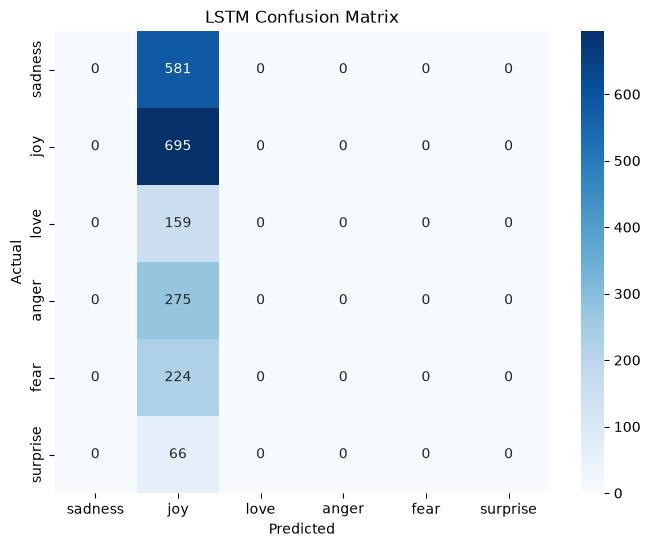

              precision    recall  f1-score   support

     sadness       0.00      0.00      0.00       581
         joy       0.35      1.00      0.52       695
        love       0.00      0.00      0.00       159
       anger       0.00      0.00      0.00       275
        fear       0.00      0.00      0.00       224
    surprise       0.00      0.00      0.00        66

    accuracy                           0.35      2000
   macro avg       0.06      0.17      0.09      2000
weighted avg       0.12      0.35      0.18      2000



c:\Krishna_Great_Productions\Sentimental\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Krishna_Great_Productions\Sentimental\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Krishna_Great_Productions\Sentimental\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

array([[  0, 581,   0,   0,   0,   0],
       [  0, 695,   0,   0,   0,   0],
       [  0, 159,   0,   0,   0,   0],
       [  0, 275,   0,   0,   0,   0],
       [  0, 224,   0,   0,   0,   0],
       [  0,  66,   0,   0,   0,   0]])

In [28]:
plot_confusion_matrix(lstm_model, padded_test_sequences, test_labels, labels_names, "LSTM Confusion Matrix")

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step


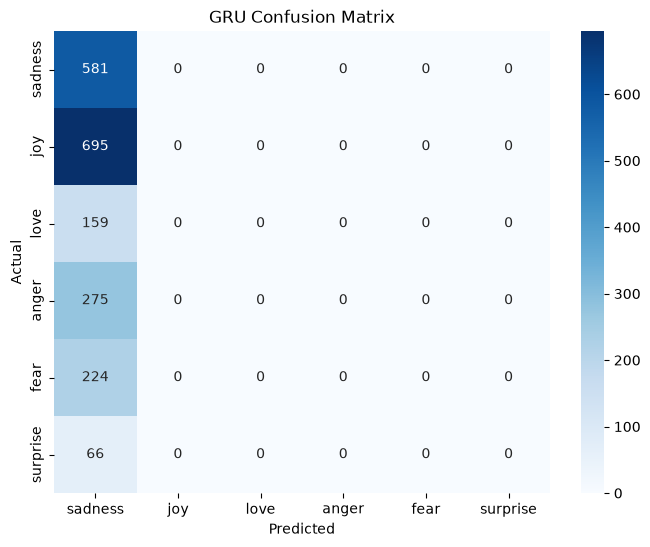

              precision    recall  f1-score   support

     sadness       0.29      1.00      0.45       581
         joy       0.00      0.00      0.00       695
        love       0.00      0.00      0.00       159
       anger       0.00      0.00      0.00       275
        fear       0.00      0.00      0.00       224
    surprise       0.00      0.00      0.00        66

    accuracy                           0.29      2000
   macro avg       0.05      0.17      0.08      2000
weighted avg       0.08      0.29      0.13      2000



c:\Krishna_Great_Productions\Sentimental\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Krishna_Great_Productions\Sentimental\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Krishna_Great_Productions\Sentimental\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

array([[581,   0,   0,   0,   0,   0],
       [695,   0,   0,   0,   0,   0],
       [159,   0,   0,   0,   0,   0],
       [275,   0,   0,   0,   0,   0],
       [224,   0,   0,   0,   0,   0],
       [ 66,   0,   0,   0,   0,   0]])

In [29]:
plot_confusion_matrix(gru_model, padded_test_sequences, test_labels, labels_names, "GRU Confusion Matrix")

63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step


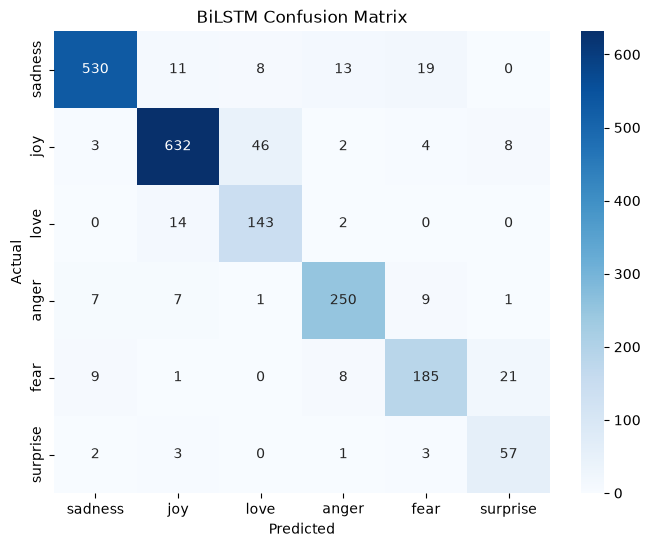

              precision    recall  f1-score   support

     sadness       0.96      0.91      0.94       581
         joy       0.95      0.91      0.93       695
        love       0.72      0.90      0.80       159
       anger       0.91      0.91      0.91       275
        fear       0.84      0.83      0.83       224
    surprise       0.66      0.86      0.75        66

    accuracy                           0.90      2000
   macro avg       0.84      0.89      0.86      2000
weighted avg       0.91      0.90      0.90      2000



array([[530,  11,   8,  13,  19,   0],
       [  3, 632,  46,   2,   4,   8],
       [  0,  14, 143,   2,   0,   0],
       [  7,   7,   1, 250,   9,   1],
       [  9,   1,   0,   8, 185,  21],
       [  2,   3,   0,   1,   3,  57]])

In [30]:
plot_confusion_matrix(bilstm_model, padded_test_sequences, test_labels, labels_names, "BiLSTM Confusion Matrix")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


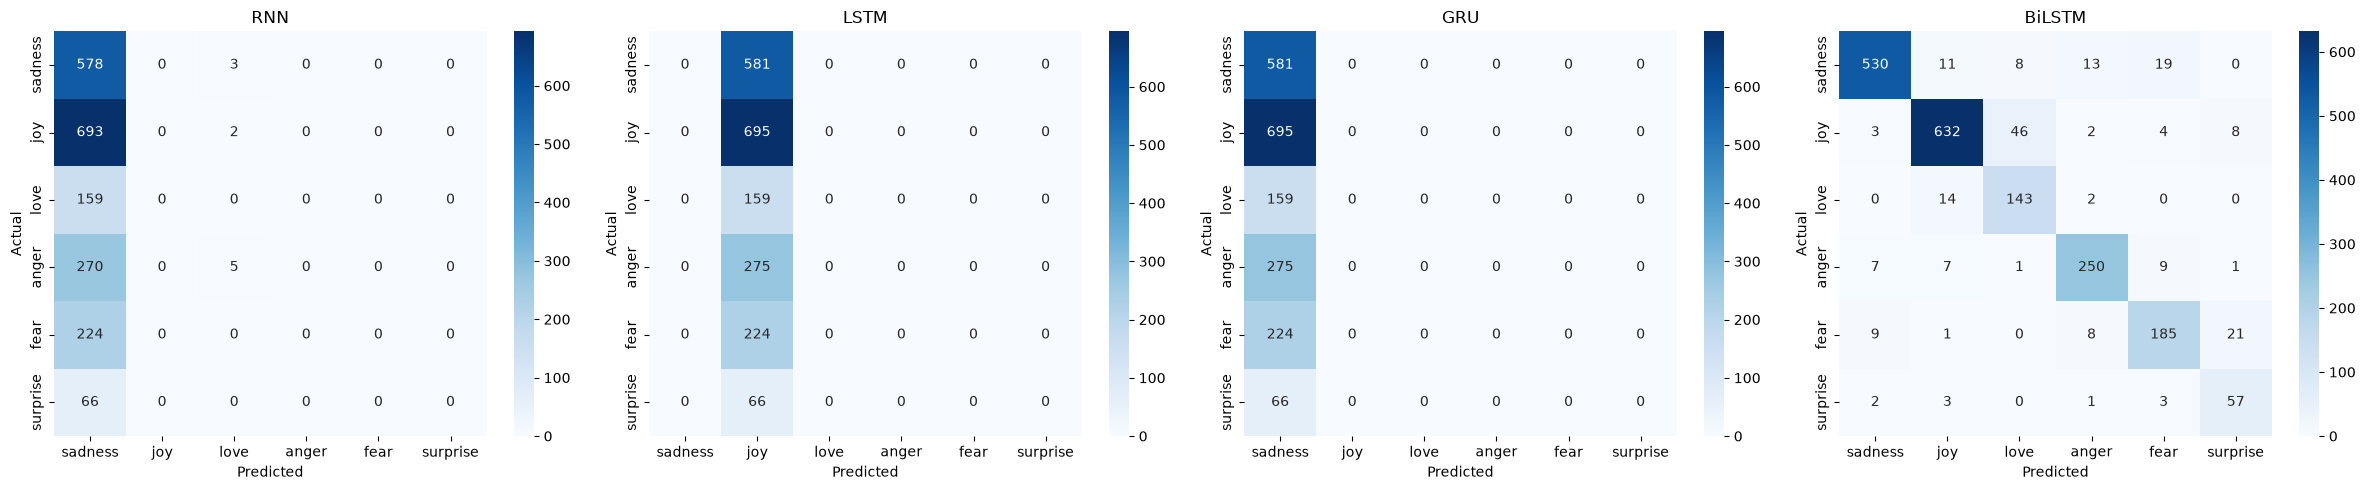

In [31]:
models_dict = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model,
    "BiLSTM": bilstm_model
}

fig, axes = plt.subplots(1, len(models_dict), figsize=(6*len(models_dict), 5))

for ax, (name, model) in zip(axes, models_dict.items()):
    y_pred = np.argmax(model.predict(padded_test_sequences), axis=1)
    cm = confusion_matrix(test_labels, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels_names, yticklabels=labels_names, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [37]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]
sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences,maxlen = 50,padding="post",truncating='post')
sample_predection = np.argmax(bilstm_model.predict(sample_padded_sequences),axis=1)
sample_predection

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


array([4, 0, 3, 4, 5])

In [38]:
for i in range(len(sample_texts)):
    print(f"Text: {sample_texts[i]}\nPredicted Emotion: {labels_names[sample_predection[i]]}")

Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: fear
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


In [42]:
import os
import pickle
model_dir = "Shaniwaar"
os.makedirs(model_dir, exist_ok=True)
bilstm_model.save(os.path.join(model_dir,'BiGRU_Model.keras'))

with open(os.path.join(model_dir,'tokenizer.pkl'),'wb') as file:
    pickle.dump(tokenizer,file)